Lea Frost \
CSCE 580 \
Code for Q3 on Quiz 1

Load in data

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

datafile = "./Redacted-Department _ CAD Reconciliation.csv"

# Read data from local file
data = pd.read_csv(datafile)
data.head()
type(data)

pandas.core.frame.DataFrame

#### a) Data issues

1. What is the range of data for the cases (dispatches) ? 

In [2]:
# Range of dispatch dates
data["DISPATCH CREATED DATE"] = pd.to_datetime(data["DISPATCH CREATED DATE"], errors="coerce", infer_datetime_format=True)
#print(dispatch_dates)

start = data["DISPATCH CREATED DATE"].min()
end = data["DISPATCH CREATED DATE"].max()

print("Range:", start, "to", end)

time_length = end - start

print("Length:", time_length)


Range: 2025-03-24 15:54:00 to 2025-08-31 23:03:00
Length: 160 days 07:09:00


2. What % of data is missing, by each column?

In [3]:
missing = data.isna().mean() * 100
print("Percent missing by column:")
print(missing)

Percent missing by column:
XREF ID                   0.000000
DISPATCH UNIT             0.000000
DISPATCH CREATED DATE     0.000000
INCIDENT NUMBER           0.000000
1ST UNIT ON SCENE        19.454545
ALARM DATE TIME           1.409091
CALL COMPLETE             1.409091
SHIFT                     3.136364
dtype: float64


3. What data issues are there (e.g., different formats) and how we can resolve them

Issues:
- There are a decent number of missing values, especially in the 1st Unit on scene column. 
- For the dispatch unit column, there are different amounts of dispatch units
- The columns use different formats from eachother, e.g. dates vs unit vs shift letter
- Need to convert times to standardized times
- Units have different formats in the dispatch unit vs 1st unit on scene column (E171 vs E-171, LDR175 vs L-175)
- Some of the incident numbers have 00 instead of -

Solutions:
- For the 1st unit on scene column, the missing values will be left as NA to form its own category
- Dispatch units will have to be stored as a list
- Standardize the unit names by removing hyphens and choosing the shortest name
- Replace 00 with - 

4. Resolve data issues. Assign IDs. Pick a method for handling missing data and use consistently. Describe
your data cleaning strategy, as appropriate. Do remainder of the tasks with data resolved.

In [4]:
# Assign IDs as XREF ID
data = data.set_index("XREF ID")
print(data)

                   DISPATCH UNIT DISPATCH CREATED DATE INCIDENT NUMBER  \
XREF ID                                                                  
2025107105  BAT111, E171, LDR175   2025-03-24 15:54:00         25-1368   
2025107223                BAT111   2025-03-24 17:28:00         25-1369   
2025107415                  E171   2025-03-24 21:03:00         25-1370   
2025107411                  E171   2025-03-24 21:03:00         25-1371   
2025107384  BAT111, E171, LDR175   2025-03-24 21:43:00         25-1374   
...                          ...                   ...             ...   
2025326268                LDR175   2025-08-31 12:28:00         25-4052   
2025326380                LDR175   2025-08-31 14:18:00         25-4053   
2025326497    BAT111, E171, E172   2025-08-31 15:53:00         25-4054   
2025326555                  E171   2025-08-31 16:48:00         25-4055   
2025326922                LDR175   2025-08-31 23:03:00         25-4056   

           1ST UNIT ON SCENE ALARM DA

Standardize times (date created already done)

In [5]:
data["ALARM DATE TIME"] = pd.to_datetime(data["ALARM DATE TIME"], errors="coerce", infer_datetime_format=True)
data["CALL COMPLETE"] = pd.to_datetime(data["CALL COMPLETE"], errors="coerce", infer_datetime_format=True)

Standardize unit names

In [6]:
# Split and strip dispatch unit column
data["DISPATCH UNIT"] = data["DISPATCH UNIT"].str.split(",").apply(
    lambda x: [u.strip() for u in x] if isinstance(x, list) else x)
print(data["DISPATCH UNIT"])

XREF ID
2025107105    [BAT111, E171, LDR175]
2025107223                  [BAT111]
2025107415                    [E171]
2025107411                    [E171]
2025107384    [BAT111, E171, LDR175]
                       ...          
2025326268                  [LDR175]
2025326380                  [LDR175]
2025326497      [BAT111, E171, E172]
2025326555                    [E171]
2025326922                  [LDR175]
Name: DISPATCH UNIT, Length: 2200, dtype: object


In [7]:
# Get unique DISPATCH UNIT units

# Split units by splitting by commas, exploding, and stripping whitespace
units_dispatch = data["DISPATCH UNIT"].explode()

# print(units)

# Get list of all unique unit names from dispatch unit column
unique_units_dispatch = units_dispatch.unique()
print(unique_units_dispatch)

['BAT111' 'E171' 'LDR175' 'E172' 'C102' 'C108' 'C103' 'E173' 'B117' 'C107'
 'SRT117' 'E174' 'M105' 'C101' 'RG170']


In [8]:
# Get unique 1ST UNIT ON SCENE units

# Split units by splitting by commas, exploding, and stripping whitespace
units_1st = data["1ST UNIT ON SCENE"].str.split(",").explode().str.strip()

# print(units_1st)

# Get list of all unique unit names from dispatch unit column
unique_units_1st = units_1st.unique()
print(unique_units_1st)

['BC-111' 'E-171' nan 'L-175' 'E-172' 'C-102' 'C-103' 'C-108' 'C-107'
 'SRT-117' 'M-105']


In [9]:
# Figure out which names refer to the same unit

# BC-111->  BAT111
# E-171 ->  E171
# E-172 ->  E172
# L-175 ->  LDR175
# C-102 ->  C102
# C-103 ->  C103
# C-107 ->  C107
# C-108 ->  C108
# SRT-117   -> SRT177
# M-105 ->  M105

# Choose format for others
# RG170 ->  keep
# E173  ->  keep
# E174  ->  keep
# C101  ->  keep
# B117  ->  keep

unit_dict = {
    "BC-111": "BAT111",
    "E-171" : "E171",
    "E-172" : "E172",
    "L-175" : "L175",
    "LDR175": "L175",
    "C-102" : "C102",
    "C-103" : "C103",
    "C-107" : "C107",
    "C-108" : "C108",
    "SRT-117" : "SRT117",
    "M-105" : "M105"
}

# Replace nan with "Unknown"
data["DISPATCH UNIT"].fillna(value="Unknown")
data["1ST UNIT ON SCENE"].fillna(value="Unknown") # doesn't work?
data["1ST UNIT ON SCENE"] = data["1ST UNIT ON SCENE"].replace(float('nan'), 'Unknown')

# Replace dispatch units
data["DISPATCH UNIT"] = data["DISPATCH UNIT"].apply(
    lambda x: [unit_dict.get(u, u) for u in x] if isinstance(x, list) else x)

# Verify correctness
print(data["DISPATCH UNIT"].explode().unique())


# Replace 1st units
data["1ST UNIT ON SCENE"] = data["1ST UNIT ON SCENE"].apply(
    lambda x: [unit_dict.get(u, u) for u in x] if isinstance(x, list) else x
)
# Verify correctness
print(data["1ST UNIT ON SCENE"].explode().unique())


['BAT111' 'E171' 'L175' 'E172' 'C102' 'C108' 'C103' 'E173' 'B117' 'C107'
 'SRT117' 'E174' 'M105' 'C101' 'RG170']
['BC-111' 'E-171' 'Unknown' 'L-175' 'E-172' 'C-102' 'C-103' 'C-108'
 'C-107' 'SRT-117' 'M-105']


Standardize Incident numbers

In [10]:
# Replace 2500 with 25-
data["INCIDENT NUMBER"] = data["INCIDENT NUMBER"].str.replace(r"^2500", "25-", regex=True)

#### b) Exploratory data analysis

1. On an average, in how much time is a call (alarm) resolved from the time it is created to closed ?

In [11]:
data["DURATION"] = (data["CALL COMPLETE"] - data["ALARM DATE TIME"])
avg_resolve = (data["DURATION"]).mean()
print("Average time between alarm and marked complete")
print(avg_resolve)

Average time between alarm and marked complete
90 days 18:28:08.907330567


2. How many fire units, on an average, are usually sent for a fire alarm?

In [12]:
data["NUM_UNITS"] = data["DISPATCH UNIT"].apply(lambda x: len(x) if isinstance(x, list) else 1)
average_units = data["NUM_UNITS"].mean()
print("Average number of units sent:")
print(round(average_units, 3))

Average number of units sent:
1.441


3. Which shift is the busiest among A, B, C ?

In [13]:
shift_counts = data["SHIFT"].value_counts()
print("Shift counts:")
print(shift_counts)
print("\nBusiest shift:")
print("Shift", shift_counts.idxmax(), "with", shift_counts.max(), "occurences")

Shift counts:
SHIFT
A    735
C    719
B    677
Name: count, dtype: int64

Busiest shift:
Shift A with 735 occurences


4. Create a matrix of number of file alarms organized by the day of week (x_axis) and hour of the day (yaxis). It will also have totals for each row and column. See illustration below.

In [14]:
# Initialize dataframe
alarms = pd.DataFrame(columns=['HOUR', 'SUNDAY', 'MONDAY', 'TUESDAY', 'WEDNESDAY', 
                               'THURSDAY', 'FRIDAY', 'SATURDAY', 'TOTAL'])
alarms['HOUR'] = [f"{h:02d}:00" for h in range(24)]
alarms = alarms.fillna(0)
alarms = alarms.set_index('HOUR')

In [15]:
# match 
weekday_map = {
    0: "MONDAY",
    1: "TUESDAY",
    2: "WEDNESDAY",
    3: "THURSDAY",
    4: "FRIDAY",
    5: "SATURDAY",
    6: "SUNDAY"
}

# iterate through all cases, also calculate day, hour
for index, row in data.iterrows():
    if pd.isna(row["ALARM DATE TIME"]): # If alarm NA, use dispatch
        alarm_time = row["DISPATCH CREATED DATE"]
    else: #default to alarm
        alarm_time = row["ALARM DATE TIME"]

        
    hour = alarm_time.hour # get hour
    hour = f"{hour:02d}:00" # change to correct label
    day = alarm_time.weekday() # get weekday (int)
    day = weekday_map[day] # change to correct label
    alarms.at[hour, day] += 1
print(alarms)


       SUNDAY  MONDAY  TUESDAY  WEDNESDAY  THURSDAY  FRIDAY  SATURDAY  TOTAL
HOUR                                                                        
00:00       4       8        7          6         2       3         7      0
01:00      10      11       10          8         8       4         8      0
02:00      10       5        4          3         3       3         8      0
03:00       7       9        9          9         1      10         5      0
04:00       4       3        4          5         2       7         6      0
05:00       7       9        3          6         5       5         3      0
06:00       9       5        5          7         7      11         7      0
07:00      11      15       15          9        10      14         5      0
08:00      14      13       14         18        10       7         6      0
09:00      14      10       17         14        14      16        12      0
10:00      11      20       24         18        15      14        16      0

Calculate total and counts

In [16]:
days =  ["SUNDAY","MONDAY","TUESDAY","WEDNESDAY","THURSDAY","FRIDAY","SATURDAY"]

alarms["TOTAL"] = alarms[days].sum(axis=1) # calculate hour totals
totals = alarms[days + ["TOTAL"]].sum() # calculate day totals
alarms.loc["Count of Incidents"] = totals

print(alarms)

                    SUNDAY  MONDAY  TUESDAY  WEDNESDAY  THURSDAY  FRIDAY  \
HOUR                                                                       
00:00                    4       8        7          6         2       3   
01:00                   10      11       10          8         8       4   
02:00                   10       5        4          3         3       3   
03:00                    7       9        9          9         1      10   
04:00                    4       3        4          5         2       7   
05:00                    7       9        3          6         5       5   
06:00                    9       5        5          7         7      11   
07:00                   11      15       15          9        10      14   
08:00                   14      13       14         18        10       7   
09:00                   14      10       17         14        14      16   
10:00                   11      20       24         18        15      14   
11:00       

#### c) Unsupervised learning

1. Cluster the data based on any two methods in sci-kit and report on their cluster quality. Which method performs better ?

Create numeric features for clustering

Note: I chose not to include complete time because they were marked complete months after the alarm which seems to be an error in reporting.

In [17]:
# Hour
# If alarm NA, use dispatch
data["HOUR"] = data["ALARM DATE TIME"].dt.hour.fillna(data["DISPATCH CREATED DATE"].dt.hour)

# Day
# Use alarm by default, dispatch if NA
data["DAY"] = data["ALARM DATE TIME"].dt.weekday.fillna(data["DISPATCH CREATED DATE"].dt.weekday)
    
# Shift
# If NA, use value above
shift_map = {"A": 0, "B": 1, "C": 2}
data["SHIFT_CODE"] = data["SHIFT"].map(shift_map).fillna(method="ffill")

# Time between alarm and dispatch (minutes)
# For na, fill with median
alarm_dispatch = (data["DISPATCH CREATED DATE"] - data["ALARM DATE TIME"]).dt.total_seconds()
data["ALARM_DISPATCH_DURATION"] = alarm_dispatch.fillna(alarm_dispatch.median()) /60

#print(data)


Prepare data for models

In [18]:
from sklearn.preprocessing import StandardScaler

# Select features
# DAY, HOUR, SHIFT_CODE, NUM_UNITS, ALARM_DISPATCH_DURATION
X = data[["HOUR", "DAY", "SHIFT_CODE","NUM_UNITS", "ALARM_DISPATCH_DURATION"]]
#print(X)
X.isnull().any()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)


[[ 0.28261863 -1.45016028  1.236007    2.00045064 -0.04190081]
 [ 0.62108405 -1.45016028  1.236007   -0.56572511 -0.04326947]
 [ 1.29801489 -1.45016028  1.236007   -0.56572511 -0.04509435]
 ...
 [ 0.28261863  1.56244842  0.02261325  2.00045064 -0.04418191]
 [ 0.45185134  1.56244842  0.02261325 -0.56572511 -0.04281325]
 [ 1.46724759  1.56244842  0.02261325 -0.56572511 -0.04326947]]


### K-Means

In [19]:
from sklearn.cluster import KMeans

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
k_labels = kmeans.fit_predict(X_scaled)

Evalute clustering performance

In [20]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

# Silhouette score
# from -1 to 1
ss_kmeans = silhouette_score(X_scaled, k_labels)

# calinski_harabasz_score
ch_kmeans = calinski_harabasz_score(X_scaled, k_labels)

# davies_bouldin_score
db_kmeans = davies_bouldin_score(X_scaled, k_labels)

print("BIRCH evaluation")
print("Silhouette Score:\n", round(ss_kmeans, 3))
print("calinski harabasz_score:\n", round(ch_kmeans, 1))
print("Davies Bouldin Score:\n", round(db_kmeans, 3))


BIRCH evaluation
Silhouette Score:
 0.225
calinski harabasz_score:
 656.4
Davies Bouldin Score:
 1.184


Matplotlib is building the font cache; this may take a moment.


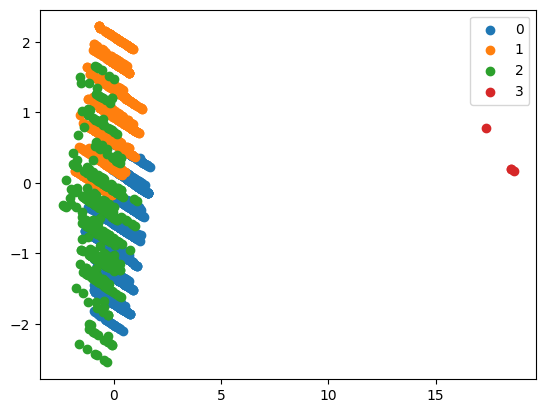

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(2)
 
#Transform the data
df = pca.fit_transform(X_scaled)
df.shape

#filter rows of original data
filtered_label0 = df[k_labels == 0]
 
u_labels = np.unique(k_labels)
 
#plotting the results:
 
for i in u_labels:
    plt.scatter(df[k_labels == i , 0] , df[k_labels == i , 1] , label = i)
plt.legend()
plt.show()

### BIRCH clustering

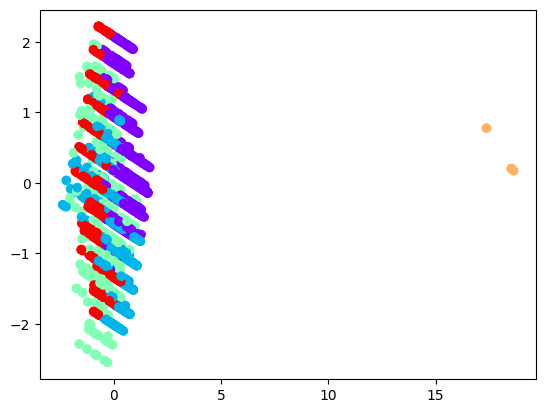

In [22]:
from sklearn.cluster import Birch
from numpy import unique
from numpy import where

# define the model
birch_model = Birch(threshold=0.1, n_clusters=5)

# train the model
birch_model.fit(X_scaled)

# assign each data point to a cluster
birch_pred = birch_model.predict(X_scaled)

# get all of the unique clusters
birch_clusters = unique(birch_pred)

# Creating a scatter plot
plt.scatter(df[:, 0], df[:, 1], c = birch_pred, cmap = 'rainbow')
plt.show()


Evaluate Birch model

In [23]:
# Silhouette score
# from -1 to 1
ss_birch = silhouette_score(X_scaled, birch_pred)

# calinski_harabasz_score
ch_birch = calinski_harabasz_score(X_scaled, birch_pred)

# davies_bouldin_score
# lower = better, 0 minimum, range about ~10
db_birch = davies_bouldin_score(X_scaled, birch_pred)

print("BIRCH evaluation")
print("Silhouette Score:\n", round(ss_birch, 3))
print("calinski harabasz_score:\n", round(ch_birch, 1))
print("Davies Bouldin Score:\n", round(db_birch, 3))


BIRCH evaluation
Silhouette Score:
 0.155
calinski harabasz_score:
 536.0
Davies Bouldin Score:
 1.37


2. Using the best result, try to interpret (label) the clusters. What do they represent?

The best results were from the k-means method. It is difficult to determine what the clusters represent, but we could make a few guesses. The clusters could split based on any of the variables. It is likely that time of day plays a large part because fires fluctuate throughout the day. The clusters might also represent different days of the week, different fire severity (e.g. more units sent, faster dispatch time). There are about 3 significant outliers. Either there is some extrordinary about these cases or it is due to error in reporting.